## Análisis de Rentabilidad Películas

El presente modelo intenta generalizar los resultados económicos de una película en el momento previo a su estreno utilizando datos como género, idioma original, costo inicial, país de producción y demás. 

Para su realización se utilizó el dataset de kaggle [Full TMDB Movies Dataset 2024](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies).

### Integrantes

- Matías Guillermo Alfaro
- Gonzalo Cuervo
- Nicolas Alberto Tonnelier
- Marina Andrea Racciatti

### Setup inicial y Carga de Datos

En esta sección, configuramos el entorno de análisis, importamos las bibliotecas necesarias y realizamos una exploración inicial de los datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import kagglehub
from scipy import stats as st
from scipy.stats import describe
from pathlib import Path
import shutil

In [2]:
# Create data directory if it doesn't exist
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Download dataset (latest version by default)
download_path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

# Copy to local data directory
csv_file = next(Path(download_path).glob("*.csv"))
local_path = data_dir / csv_file.name
shutil.copy2(csv_file, local_path)

print(f"Dataset copied to: {local_path}")

Dataset copied to: data/TMDB_movie_dataset_v11.csv


Carga del dataset

In [3]:
# Cargamos el dataset desde el directorio local de datos
data_path = "data/TMDB_movie_dataset_v11.csv"
df = pd.read_csv(data_path)

### Descripción de los datos

Dimensiones

In [4]:
print(f"Dimensiones del dataset original: {df.shape}")

Dimensiones del dataset original: (1434778, 24)


Información de columnas y tipos de datos

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1434778 entries, 0 to 1434777
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1434778 non-null  int64  
 1   title                 1434759 non-null  str    
 2   vote_average          1434778 non-null  float64
 3   vote_count            1434778 non-null  int64  
 4   status                1434778 non-null  str    
 5   release_date          1111712 non-null  str    
 6   revenue               1434778 non-null  int64  
 7   runtime               1434778 non-null  int64  
 8   adult                 1434778 non-null  bool   
 9   backdrop_path         355029 non-null   str    
 10  budget                1434778 non-null  int64  
 11  homepage              147199 non-null   str    
 12  imdb_id               671369 non-null   str    
 13  original_language     1434778 non-null  str    
 14  original_title        1434759 non-null  str  

### Análisis Exploratorio de Datos (EDA)

In [6]:
# exclude columns w/o valuable data (e.g. backdrop_path, imdb_id,..)
columns = ['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'popularity', 'genres', 'production_companies', 'production_countries', 'keywords']
df[columns].head()

,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,original_language,popularity,genres,production_companies,production_countries,keywords
0,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,160000000,en,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","rescue, mission, dream, airplane, paris, franc..."
1,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,165000000,en,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America","rescue, future, spacecraft, race against time,..."
2,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,185000000,en,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","joker, sadism, chaos, secret identity, crime f..."
3,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,237000000,en,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","future, society, culture clash, space travel, ..."
4,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,220000000,en,98.082,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"new york city, superhero, shield, based on com..."


In [7]:
df[columns].describe()

,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.434778e+06,1.434778e+06,1.434778e+06,1.434778e+06,1.434778e+06,1.434778e+06
mean,1.540522e+00,1.495565e+01,6.171536e+05,4.376399e+01,2.343101e+05,1.000623e+00
std,2.849070e+00,2.835962e+02,1.963487e+07,6.060025e+01,5.130369e+06,6.769720e+00
min,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.140000e-02
50%,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,6.000000e-01
75%,5.000000e-01,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,6.910000e-01
max,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


#### Variables numéricas

<em>Nota: hay columnas con muchos valores en 0</em>

IMDB usa el 0 para representar "unknown", no el valor 0. Por eso usamos alternativamente las siguientes medidas para obtener resultados útiles:

In [8]:
# columnas numéricas
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop('id')
print("Columnas numéricas:")
print(numerical_columns)

Columnas numéricas:
Index(['vote_average', 'vote_count', 'revenue', 'runtime', 'budget',
       'popularity'],
      dtype='str')


In [9]:
# esta función extrae max, min, mean, mode y median de cada columna numérica
# tanto para el dataset completo como para cada columna filtrando valores 0 o "unknown" (val > 0)
def extract_numerical_stats(df, columns):
    summary_data = []
    rounded_df = df[columns].round(2)  # Redondear a 2 decimales
    for column in columns:
        # unfiltered statistics
        max_value = rounded_df[column].max()
        min_value = rounded_df[column].min()
        mean_value = rounded_df[column].mean()
        mode_value = rounded_df[column].mode()[0] if not rounded_df[column].mode().empty else None
        median_value = rounded_df[column].median()
        unique_values = rounded_df[column].nunique()

        # filtered statistics (val > 0)
        filtered_df = rounded_df[rounded_df[column] > 0]
        filtered_min = filtered_df[column].min()
        filtered_mean = filtered_df[column].mean()
        filtered_mode = filtered_df[column].mode()[0] if not filtered_df[column].mode().empty else None
        filtered_median = filtered_df[column].median()
        filtered_unique_values = filtered_df[column].nunique()
        summary_data.append({
            'Column': column,
            'Max': max_value,
            'Min': min_value,
            'Filtered Min': filtered_min,
            'Mean': mean_value,
            'Filtered Mean': filtered_mean,
            'Mode': mode_value,
            'Filtered Mode': filtered_mode,
            'Median': median_value,
            'Filtered Median': filtered_median,
            'Unique Values': unique_values,
            'Filtered Unique Values': filtered_unique_values
        })
    return pd.DataFrame(summary_data)

numerical_stats_df = extract_numerical_stats(df, numerical_columns)
float_cols = numerical_stats_df.select_dtypes('float').columns
display(numerical_stats_df.style.format('{:.2f}', subset=float_cols))

,Column,Max,Min,Filtered Min,Mean,Filtered Mean,Mode,Filtered Mode,Median,Filtered Median,Unique Values,Filtered Unique Values
0,vote_average,10.00,0.00,0.50,1.54,6.16,0.00,6.00,0.00,6.00,776,775
1,vote_count,34495.00,0.00,1.00,14.96,59.76,0.00,1.00,0.00,2.00,3598,3597
2,revenue,4999999999.00,-12.00,1.00,617153.60,36133126.65,0.00,1.00,0.00,773533.00,14655,14653
3,runtime,14400.00,-28.00,1.00,43.76,63.50,0.00,90.00,15.00,61.00,822,820
4,budget,999999999.00,0.00,1.00,234310.07,4061210.36,0.00,100.00,0.00,3000.00,6629,6628
5,popularity,2994.36,0.00,0.01,1.00,1.21,0.60,0.60,0.60,0.60,4746,4745


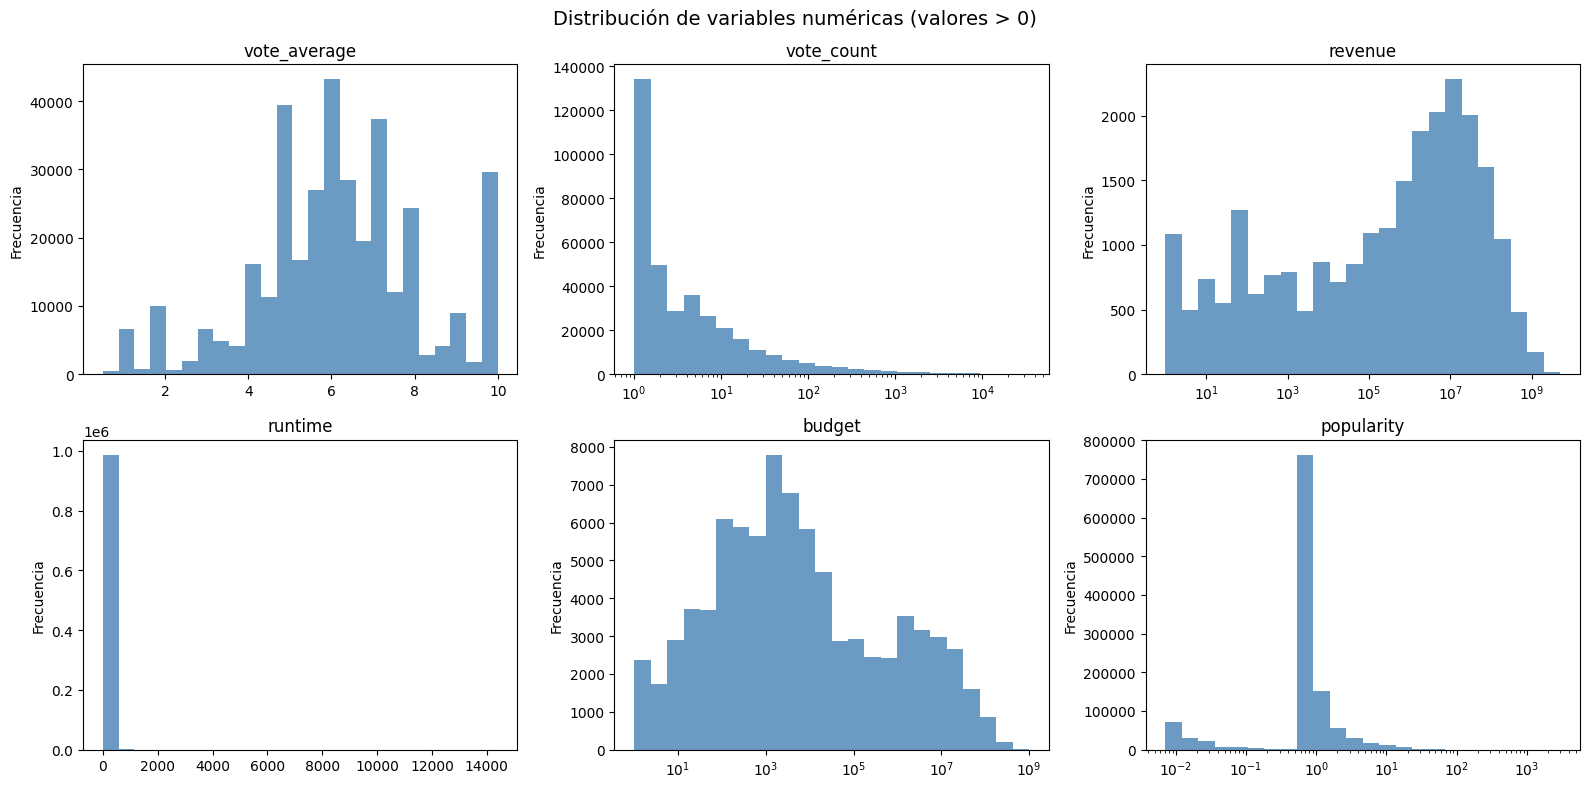

In [10]:
log_scale_cols = {'revenue', 'budget', 'vote_count', 'popularity'}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    data = df[col][df[col] > 0]
    if col in log_scale_cols:
        bins = np.geomspace(data.min(), data.max(), 25)
        axes[i].set_xscale('log')
    else:
        bins = 25
    axes[i].hist(data, bins=bins, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas (valores > 0)', fontsize=14)
plt.tight_layout()
plt.show()

#### Variables categóricas

In [11]:
categorical_columns = [
    "original_language",
    "genres",
    "production_countries",
    "production_companies",
]

df[categorical_columns].head()

,original_language,genres,production_countries,production_companies
0,en,"Action, Science Fiction, Adventure","United Kingdom, United States of America","Legendary Pictures, Syncopy, Warner Bros. Pict..."
1,en,"Adventure, Drama, Science Fiction","United Kingdom, United States of America","Legendary Pictures, Syncopy, Lynda Obst Produc..."
2,en,"Drama, Action, Crime, Thriller","United Kingdom, United States of America","DC Comics, Legendary Pictures, Syncopy, Isobel..."
3,en,"Action, Adventure, Fantasy, Science Fiction","United States of America, United Kingdom","Dune Entertainment, Lightstorm Entertainment, ..."
4,en,"Science Fiction, Action, Adventure",United States of America,Marvel Studios


Top 15 por variable:

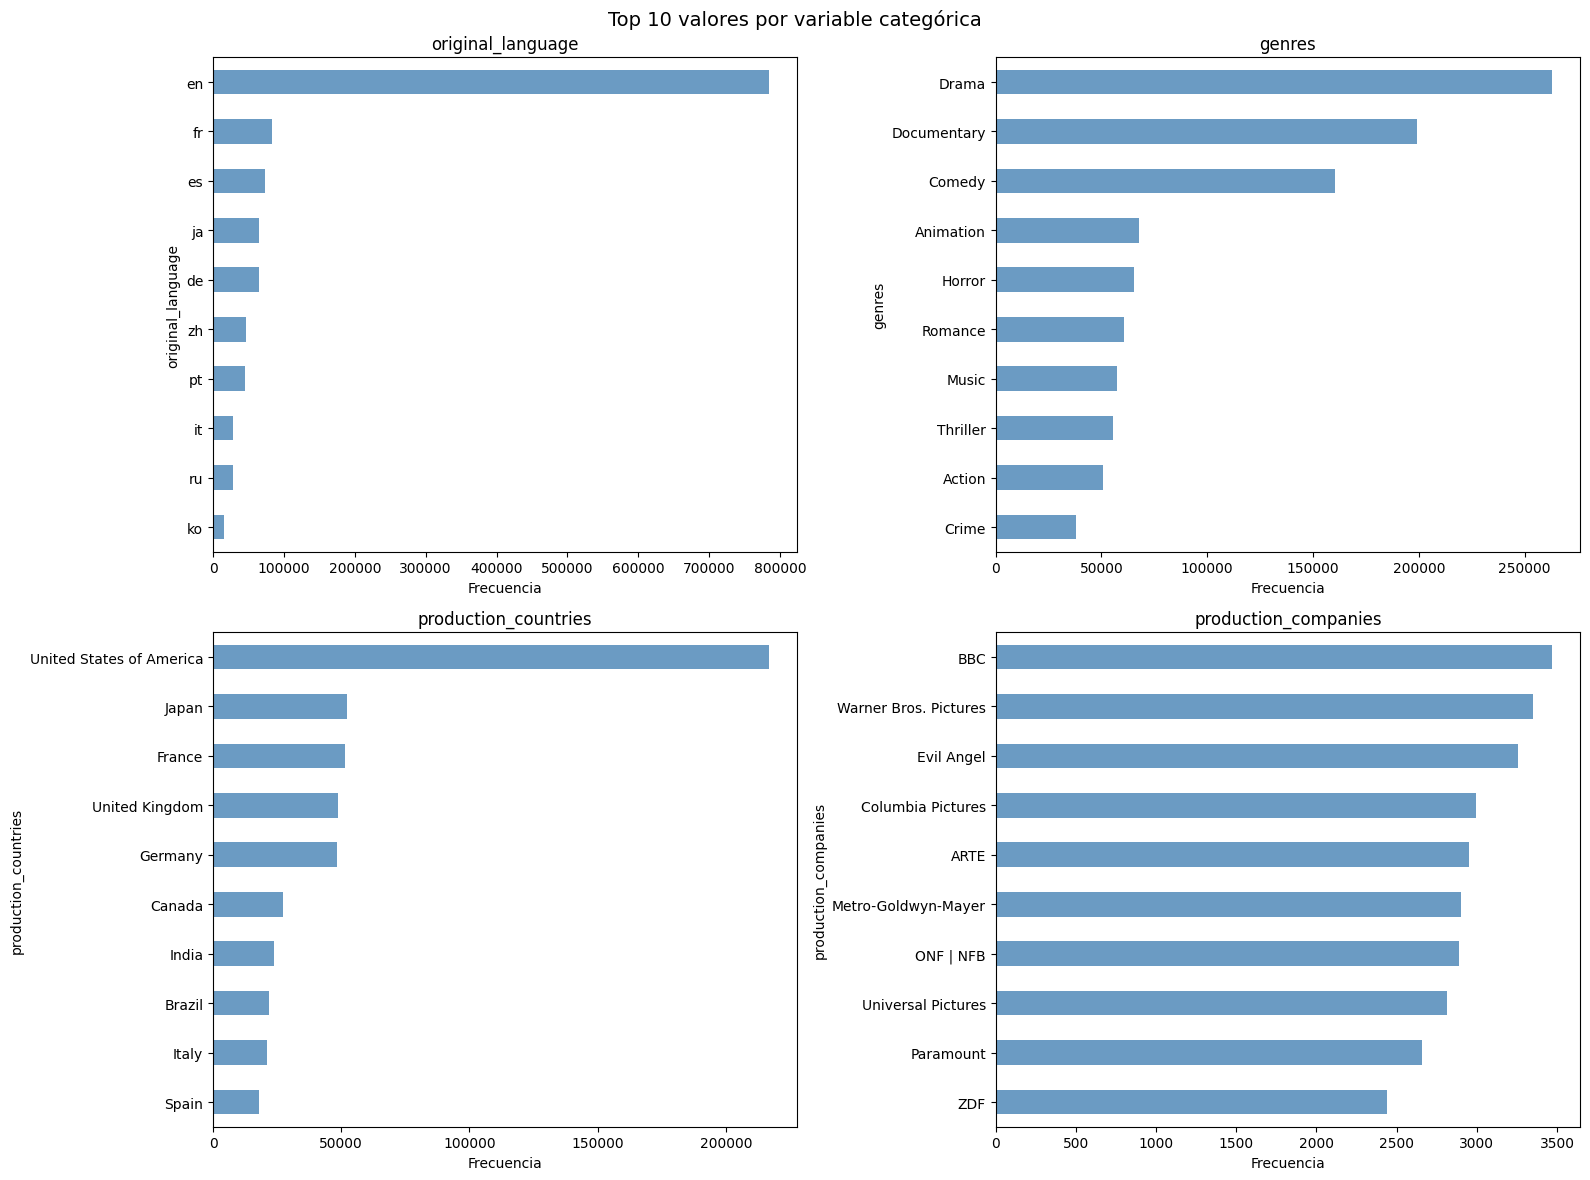

In [12]:
# Parse multi-value columns from comma-separated strings to lists
for col in ['genres', 'production_countries', 'production_companies']:
    df[col] = df[col].fillna('').apply(lambda x: [v.strip() for v in x.split(',') if v.strip()])

# Top-15 value counts per categorical column
cat_counts = {
    'original_language':    df['original_language'].value_counts(),
    'genres':               df.explode('genres')['genres'].value_counts(),
    'production_countries': df.explode('production_countries')['production_countries'].value_counts(),
    'production_companies': df.explode('production_companies')['production_companies'].value_counts(),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (col, counts) in enumerate(cat_counts.items()):
    counts.head(10).plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Frecuencia')

plt.suptitle('Top 10 valores por variable categórica', fontsize=14)
plt.tight_layout()
plt.show()

### Limpieza de datos

Eliminamos duplicados:

In [13]:
# eliminamos duplicados
df = df.drop_duplicates(subset='id')

Eliminamos películas para adultos:

In [14]:
df = df[df['adult'] == False]

Eliminamos entradas con runtime =< 0

In [15]:
# eliminamos entradas con valores no positivos en runtime
df = df[df['runtime'] > 0]

Eliminamos entradas con `revenue` y/o `budget` 0 en función de la variable target:

In [16]:
df_model = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

### Creación de la variable target: `profitable`

Generamos una nueva variable `profitable`, que es la que vamos a intentar predecir.

> `profitable = 1` si `revenue > budget`, en caso contrario `0`.

Este subconjunto, `df_model`, es el que usaremos para entrenamiento y evaluación.

In [17]:
df_model['profitable'] = (df_model['revenue'] > df_model['budget']).astype(int)

n_total = len(df_model)
n_prof  = df_model['profitable'].sum()
n_not   = n_total - n_prof

print(f"Películas con budget y revenue conocidos: {n_total:,}")
print(f"  Rentables:    {n_prof:,}  ({n_prof/n_total:.1%})")
print(f"  No rentables: {n_not:,}  ({n_not/n_total:.1%})")

Películas con budget y revenue conocidos: 14,513
  Rentables:    8,761  (60.4%)
  No rentables: 5,752  (39.6%)


#### Balance de clases

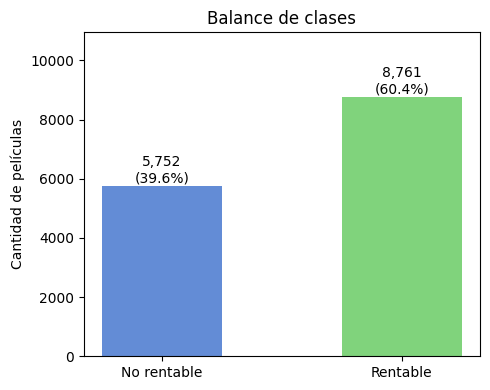

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ['No rentable', 'Rentable']
counts = [n_not, n_prof]
colors = ['#4878cf', '#6acc65']
bars = ax.bar(labels, counts, color=colors, edgecolor='none', alpha=0.85, width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{count:,}\n({count/n_total:.1%})', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Cantidad de películas')
ax.set_title('Balance de clases')
ax.set_ylim(0, max(counts) * 1.25)
plt.tight_layout()
plt.show()

### EDA con variable target

#### Variables numéricas según rentabilidad

Usamos violin plots para visualizar la distribución de cada variable numérica entre películas rentables y no rentables.

Las columnas con alta varianza (`revenue`, `budget`, `vote_count`, `popularity`) se muestran en escala logarítmica.

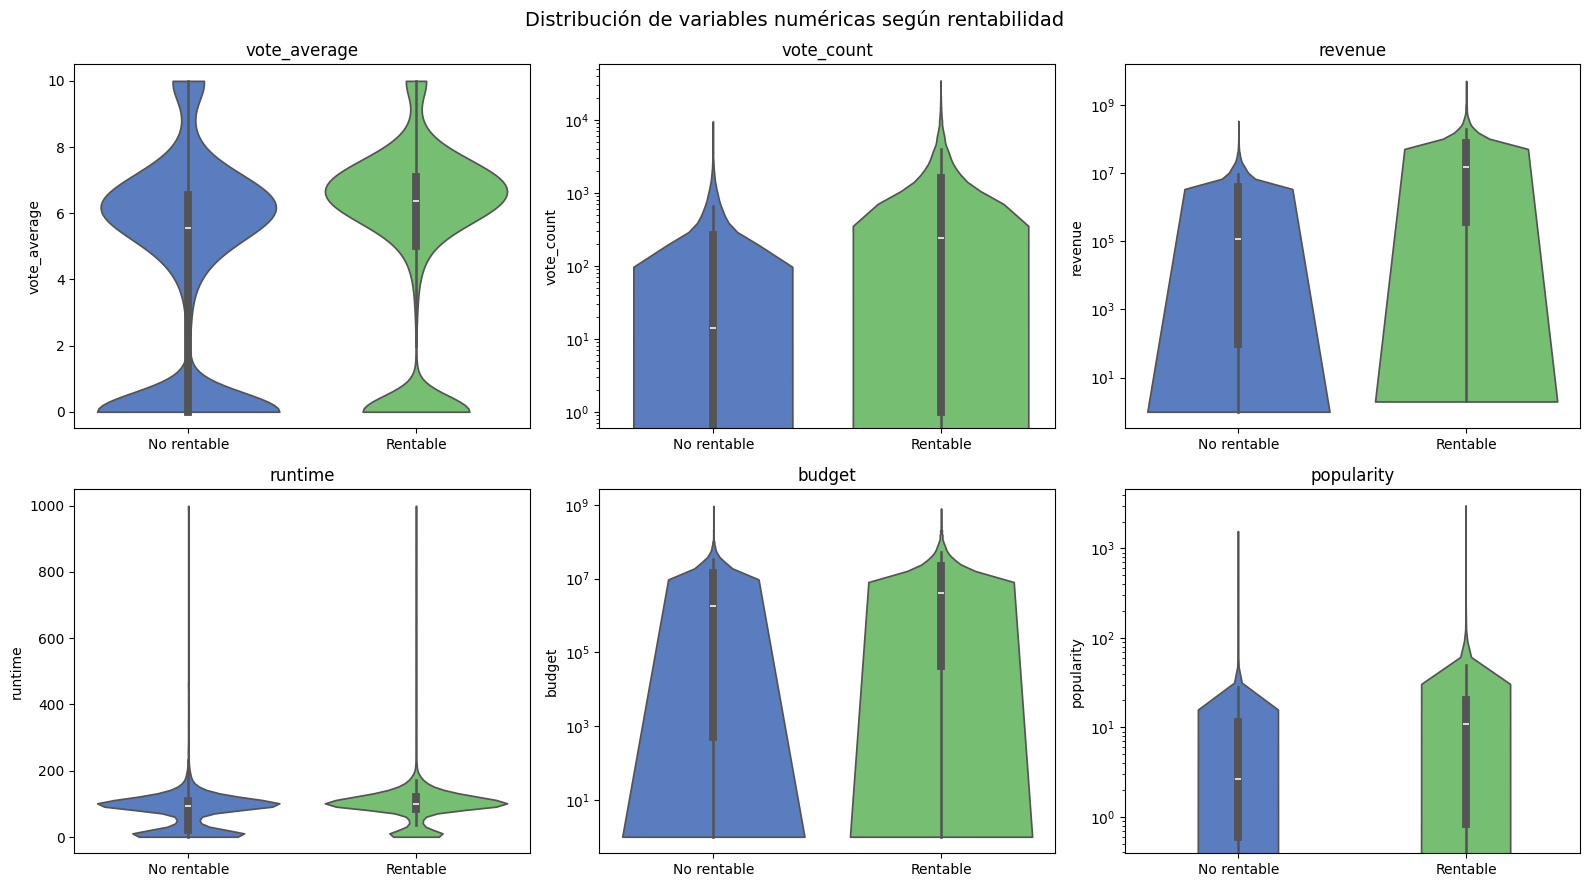

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.violinplot(
        data=df_model, x='profitable', y=col, ax=axes[i],
        hue='profitable', palette=['#4878cf', '#6acc65'],
        inner='box', cut=0, legend=False
    )
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No rentable', 'Rentable'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    if col in log_scale_cols:
        axes[i].set_yscale('log')

plt.suptitle('Distribución de variables numéricas según rentabilidad', fontsize=14)
plt.tight_layout()
plt.show()

#### Matriz de correlación

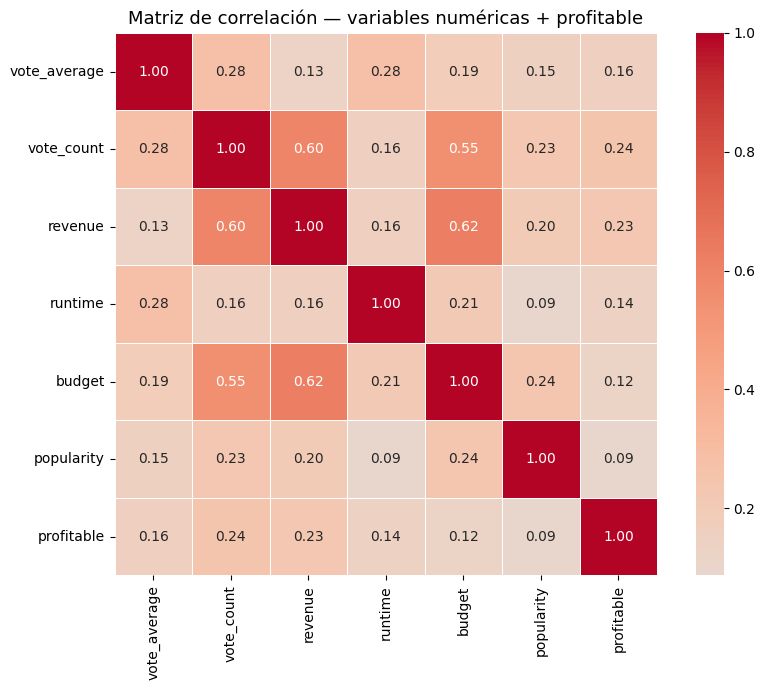

In [20]:
corr_cols = list(numerical_columns) + ['profitable']
corr = df_model[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title('Matriz de correlación — variables numéricas + profitable', fontsize=13)
plt.tight_layout()
plt.show()

#### Variables categóricas: tasa de rentabilidad

Tasa de rentabilidad por variable categórica:

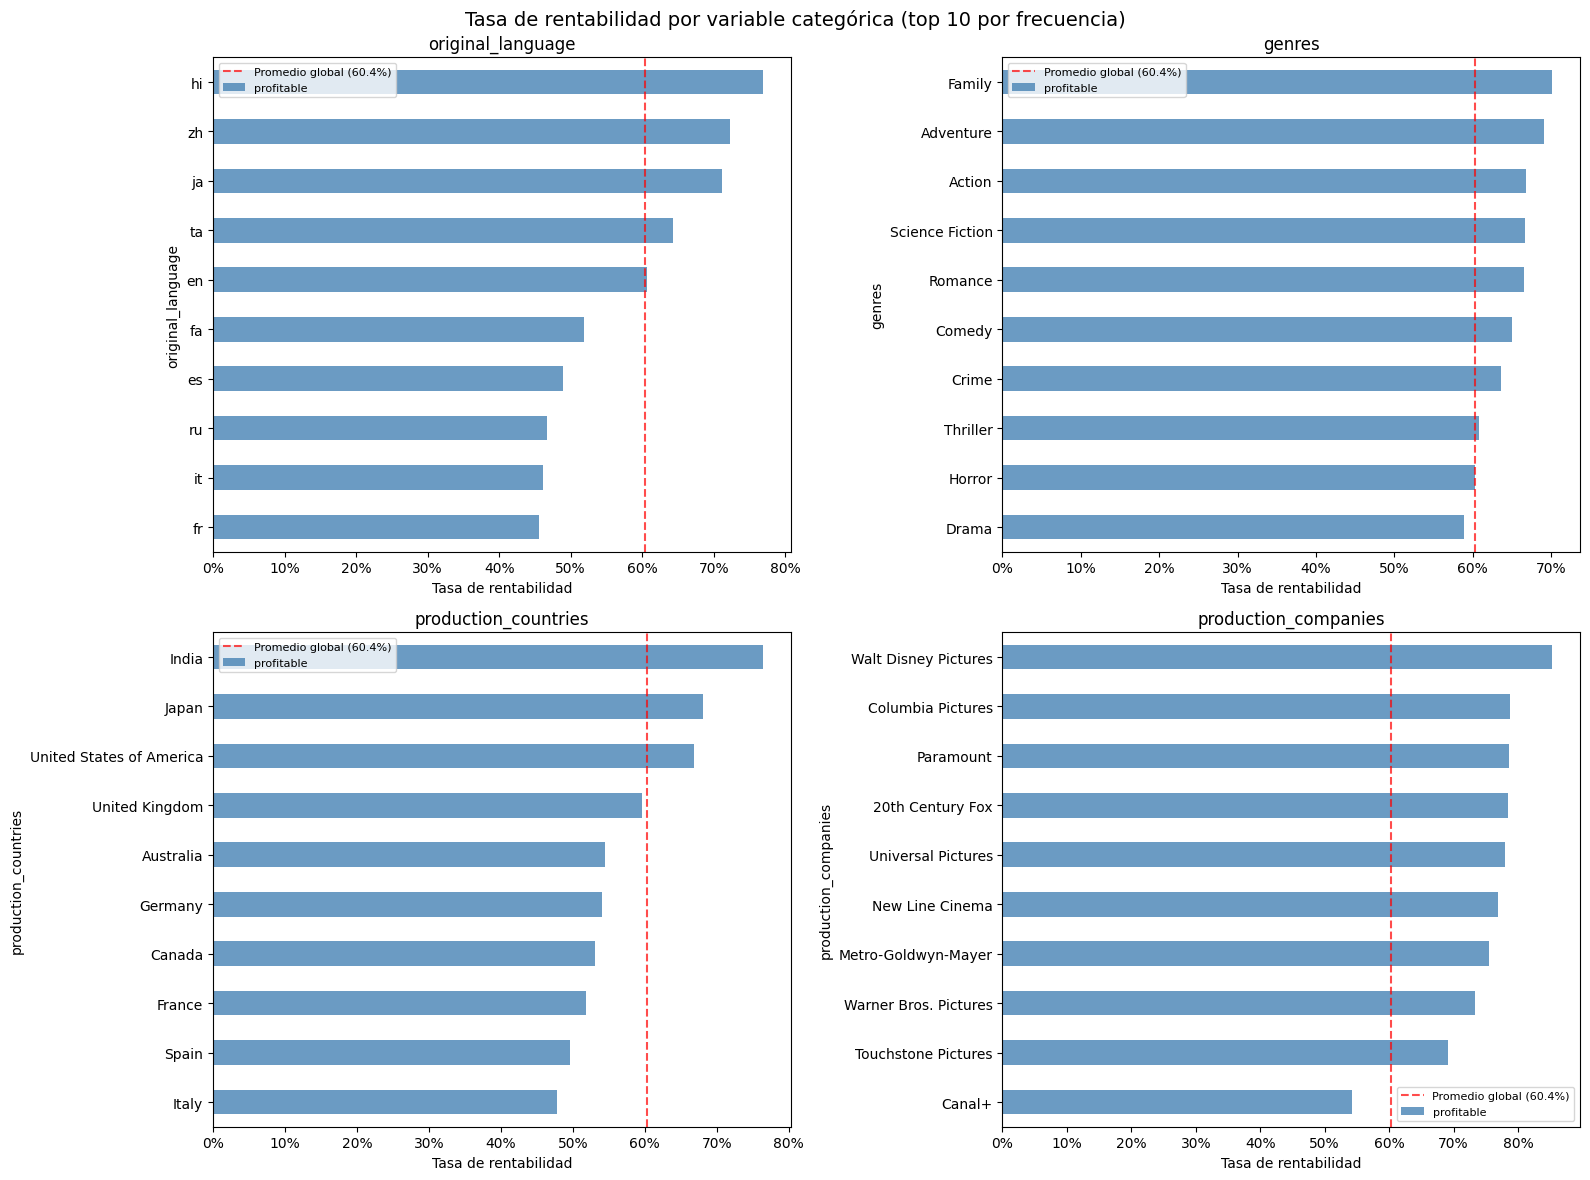

In [21]:
def profitability_rate_by_category(df, col, top_n=10):
    exploded = df.explode(col).dropna(subset=[col])
    exploded = exploded[exploded[col] != '']
    top_cats = exploded[col].value_counts().head(top_n).index
    return (
        exploded[exploded[col].isin(top_cats)]
        .groupby(col)['profitable']
        .mean()
        .sort_values(ascending=False)
    )

top_languages = df_model['original_language'].value_counts().head(10).index
lang_rate = (
    df_model[df_model['original_language'].isin(top_languages)]
    .groupby('original_language')['profitable']
    .mean()
    .sort_values(ascending=False)
)

rates = {
    'original_language':    lang_rate,
    'genres':               profitability_rate_by_category(df_model, 'genres'),
    'production_countries': profitability_rate_by_category(df_model, 'production_countries'),
    'production_companies': profitability_rate_by_category(df_model, 'production_companies'),
}

global_rate = df_model['profitable'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (col, rate) in enumerate(rates.items()):
    rate.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].axvline(global_rate, color='red', linestyle='--', alpha=0.7,
                    label=f'Promedio global ({global_rate:.1%})')
    axes[i].set_title(col)
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Tasa de rentabilidad')
    axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    axes[i].legend(fontsize=8)

plt.suptitle('Tasa de rentabilidad por variable categórica (top 10 por frecuencia)', fontsize=14)
plt.tight_layout()
plt.show()

### Ingeniería de features

Convertimos todas las variables al formato numérico que requieren los modelos.

| Variable | Transformación |
|---|---|
| `budget`, `runtime` | Se mantienen tal cual. El escalado se aplica **dentro del pipeline** de cada modelo que lo requiera (KNN, Regresión Logística, SVM). |
| `original_language` | Se conservan los `TOP_LANGUAGES` idiomas más frecuentes; el resto se agrupa como `"other"`. Luego one-hot encoding. |
| `genres` | Multi-hot encoding sobre todos los géneros presentes en el dataset. |
| `production_countries` | Multi-hot encoding sobre los `TOP_COUNTRIES` países más frecuentes. |
| `production_companies` | Multi-hot encoding sobre las `TOP_COMPANIES` productoras más frecuentes. El top-N limita el ruido por alta cardinalidad. |
| `revenue` | **Excluida**. No está disponible antes del estreno y define la variable target. |

In [22]:
from sklearn.preprocessing import MultiLabelBinarizer

TOP_LANGUAGES = 10
TOP_COUNTRIES = 20
TOP_COMPANIES = 30

df_feat = df_model[['budget', 'runtime', 'original_language',
                     'genres', 'production_countries', 'production_companies',
                     'profitable']].copy()

# 1. original_language: top-N + "other", luego one-hot
top_langs = df_feat['original_language'].value_counts().head(TOP_LANGUAGES).index
df_feat['original_language'] = df_feat['original_language'].where(
    df_feat['original_language'].isin(top_langs), other='other'
)
lang_dummies = pd.get_dummies(df_feat['original_language'], prefix='lang')

# 2. genres: multi-hot encoding
mlb_genres = MultiLabelBinarizer()
genres_enc = pd.DataFrame(
    mlb_genres.fit_transform(df_feat['genres']),
    columns=[f'genre_{g}' for g in mlb_genres.classes_],
    index=df_feat.index
)

# 3. production_countries: multi-hot encoding top-N
top_countries = (
    df_feat.explode('production_countries')['production_countries']
    .value_counts().head(TOP_COUNTRIES).index
)
df_feat['production_countries'] = df_feat['production_countries'].apply(
    lambda lst: [c for c in lst if c in top_countries]
)
mlb_countries = MultiLabelBinarizer(classes=list(top_countries))
countries_enc = pd.DataFrame(
    mlb_countries.fit_transform(df_feat['production_countries']),
    columns=[f'country_{c}' for c in mlb_countries.classes_],
    index=df_feat.index
)

# 4. production_companies: multi-hot encoding top-N
top_companies = (
    df_feat.explode('production_companies')['production_companies']
    .value_counts().head(TOP_COMPANIES).index
)
df_feat['production_companies'] = df_feat['production_companies'].apply(
    lambda lst: [c for c in lst if c in top_companies]
)
mlb_companies = MultiLabelBinarizer(classes=list(top_companies))
companies_enc = pd.DataFrame(
    mlb_companies.fit_transform(df_feat['production_companies']),
    columns=[f'company_{c}' for c in mlb_companies.classes_],
    index=df_feat.index
)

# 5. Ensamblar X e y
X = pd.concat([
    df_feat[['budget', 'runtime']],
    lang_dummies,
    genres_enc,
    countries_enc,
    companies_enc,
], axis=1)
y = df_feat['profitable']

In [23]:
feature_groups = {
    'Numéricas':            [c for c in X.columns if c in ('budget', 'runtime')],
    'Idioma':               [c for c in X.columns if c.startswith('lang_')],
    'Géneros':              [c for c in X.columns if c.startswith('genre_')],
    'Países de producción': [c for c in X.columns if c.startswith('country_')],
    'Productoras':          [c for c in X.columns if c.startswith('company_')],
}
for group, cols in feature_groups.items():
    print(f"  {group}: {len(cols)} feature{'s' if len(cols) != 1 else ''}")
print(f"\nTotal: {X.shape[1]} features | {X.shape[0]:,} muestras")
X.head()

  Numéricas: 2 features
  Idioma: 11 features
  Géneros: 19 features
  Países de producción: 20 features
  Productoras: 30 features

Total: 82 features | 14,513 muestras


,budget,runtime,lang_en,lang_es,lang_fa,lang_fr,lang_hi,lang_it,lang_ja,lang_other,...,company_Regency Enterprises,company_Film4 Productions,company_Fox Searchlight Pictures,company_Working Title Films,company_Screen Gems,company_Dimension Films,company_Amblin Entertainment,company_Orion Pictures,company_The Weinstein Company,company_Dune Entertainment
0,160000000,148,True,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,165000000,169,True,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,185000000,152,True,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,237000000,162,True,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,1
4,220000000,143,True,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


### División train / test

Separamos el dataset en un conjunto de entrenamiento (80%) y uno de evaluación (20%). Usamos `stratify=y` para garantizar que la proporción de clases sea la misma en ambos conjuntos, dado el desbalance 60/40.

In [24]:
from sklearn.model_selection import train_test_split

assert X.isna().sum().sum() == 0, "X contiene valores nulos"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} muestras  ({y_train.mean():.1%} rentables)")
print(f"Test:  {X_test.shape[0]:,} muestras  ({y_test.mean():.1%} rentables)")

Train: 11,610 muestras  (60.4% rentables)
Test:  2,903 muestras  (60.4% rentables)


### Entrenamiento y Evaluación de Modelos

Implementamos algunos modelos y evaluamos su rendimiento

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from lightgbm import LGBMClassifier

In [29]:
def train_evaluate_model(model, X_train, X_test, y_train, y_test, model_name=""):
    """
    Entrena y evalúa un modelo
    """
    model.fit(X_train, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Métricas
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    # Resultados
    print(f"\nResultados para {model_name}:")
    print("-----------------------------------")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    
    # Matriz de confusión
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()
    
    return metrics

In [30]:
# Definición de modelos
models = {
    'Regresión Logística': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'LightGBM': LGBMClassifier(random_state=42)
}

# Entrenamiento y evaluación de cada modelo
results = {}
for name, model in models.items():
    results[name] = train_evaluate_model(
        model, X_train, X_test, 
        y_train, y_test, name
    )


Resultados para Regresión Logística:
-----------------------------------
accuracy: 0.6035
precision: 0.6035
recall: 1.0000
f1: 0.7527
roc_auc: 0.6205


NameError: name 'confusion_matrix' is not defined

<Figure size 800x600 with 0 Axes>